Считайте датасет из файла train.csv (это данные о выживаемости на Титанике) - 1 балл

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Визуализируйте распределение значений признаков Survived, Pclass, Age, Sex. Parch - 2 балла

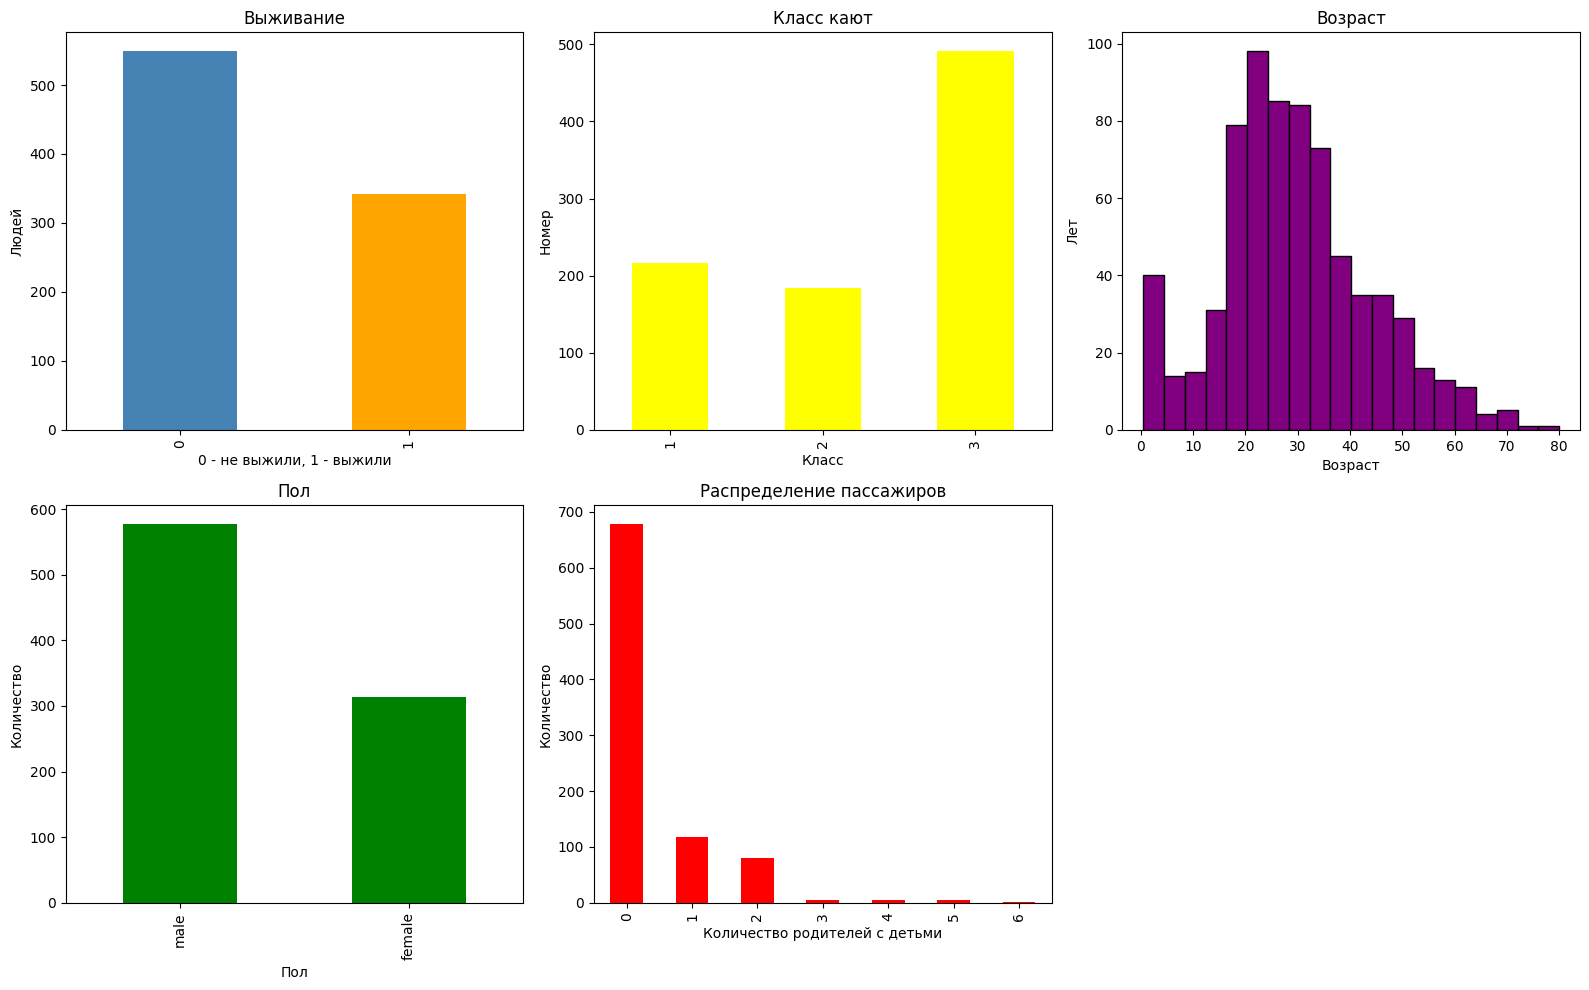

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

df['Survived'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color=['steelblue', 'orange'])
axes[0].set_title('Выживание')
axes[0].set_xlabel('0 - не выжили, 1 - выжили')
axes[0].set_ylabel('Людей')

df['Pclass'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='yellow')
axes[1].set_title('Класс кают')
axes[1].set_xlabel('Класс')
axes[1].set_ylabel('Номер')

df['Age'].dropna().plot(kind='hist', bins=20, ax=axes[2], color='purple', edgecolor='black')
axes[2].set_title('Возраст')
axes[2].set_xlabel('Возраст')
axes[2].set_ylabel('Лет')

df['Sex'].value_counts().plot(kind='bar', ax=axes[3], color='green')
axes[3].set_title('Пол')
axes[3].set_xlabel('Пол')
axes[3].set_ylabel('Количество')

df['Parch'].value_counts().sort_index().plot(kind='bar', ax=axes[4], color='red')
axes[4].set_title('Распределение пассажиров')
axes[4].set_xlabel('Количество родителей с детьми')
axes[4].set_ylabel('Количество')

axes[5].axis('off')
plt.tight_layout()
plt.show()

Постройте график типа boxplot для столбца Age - 1 балл

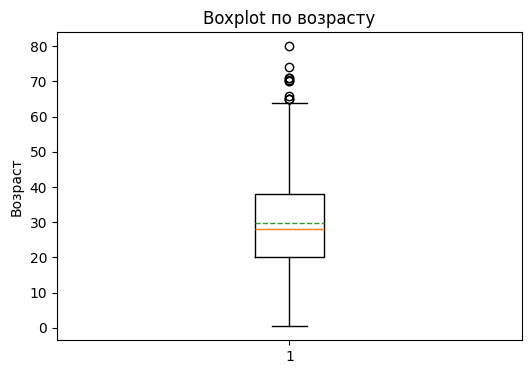

In [4]:
a = df['Age'].dropna()
fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot(a, showmeans=True, meanline=True)
ax.set_title('Boxplot по возрасту')
ax.set_ylabel('Возраст')
plt.show()


Проинтепретируйте полученный график - 1 балл

На графике видно, что медианный(оранжевый) возраст пассажиров примерно 28 лет, средний возраст(зеленый) около 30 лет, половина(50%) пассажиров от 20 до 38 лет, пассажиры старше 63 лет отображаются как выбросы. Самому старому пассажиру было около 80 лет.

Постройте график типа pie chart для переменных Survived, Pclass, подпишите доли в процентах - 1 балл

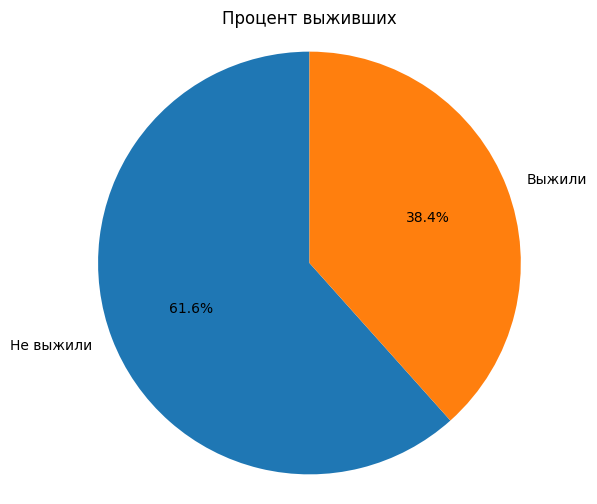

In [5]:
value = df['Survived'].value_counts().sort_index()
labels = ['Не выжили', 'Выжили']
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(value, labels=labels, autopct='%1.1f%%', startangle=90)
ax.set_title('Процент выживших')
ax.axis('equal')
plt.show()

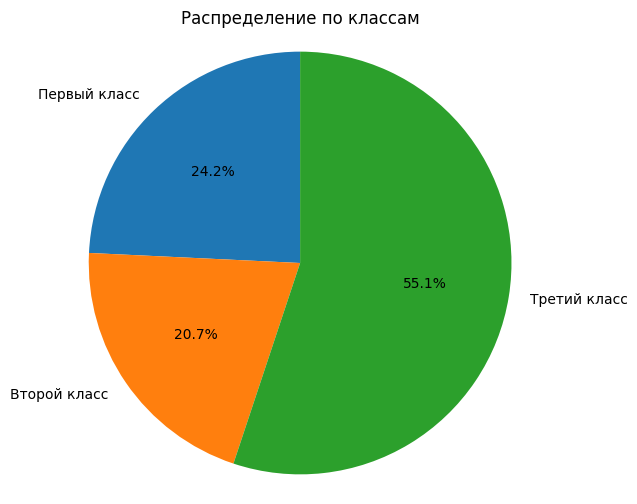

In [6]:
value = df['Pclass'].value_counts().sort_index()
labels = ['Первый класс', 'Второй класс', 'Третий класс']
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(value, labels=labels, autopct='%1.1f%%', startangle=90)
ax.set_title('Распределение по классам')
ax.axis('equal')
plt.show()

Постройте график типа pairplot для всех числовых переменных датасета - 1 балл

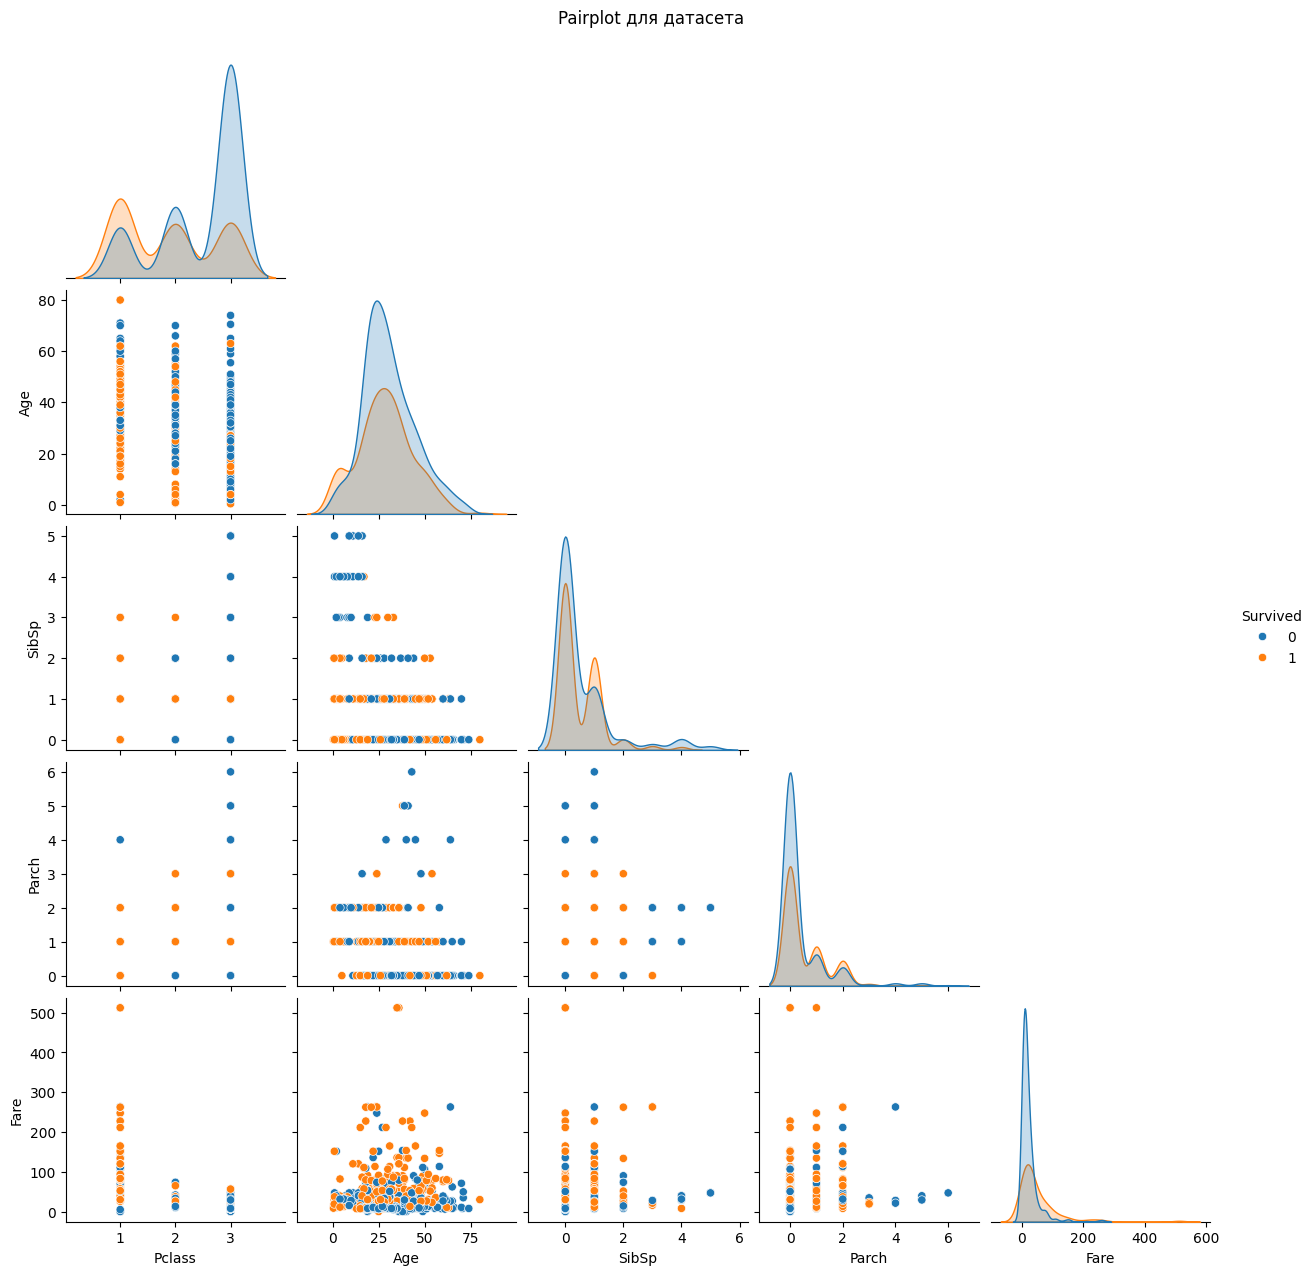

In [7]:
df2 = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].dropna()
sns.pairplot(df2, hue='Survived', corner=True)
plt.suptitle('Pairplot для датасета', y=1.02)
plt.show()

Постройте интерактивный sunburst plot (визуализация иерархических данных) с помощью plotly. На первом уровне иерархии - количество пассажиров в каждом из классов, а на втором количество женщин/мужчин в этом классе - 2 балла

In [8]:
df = pd.read_csv('train.csv')
data = df.groupby(['Pclass', 'Sex']).size().reset_index(name='value')
data['Pclass'] = data['Pclass'].map({1: '1 класс', 2: '2 класс', 3: '3 класс'})

fig = px.sunburst(
    data,
    path=['Pclass', 'Sex'],
    values='value',
    title='Распределение по классу и полу'
)
fig.show()

Снабдите все построенные графики наименованиями (title), подписями осей, легендами - 1 балл